In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('..')
import sourse
import os
import sourse_new
import matplotlib.patches as patches
plt.rcParams["font.size"] = 14

In [5]:
sim_ref = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
exp_ref = sourse_new.import_data(0, 0)[0]

sim_rough = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch150_depth20.csv")
exp_rough = sourse_new.import_data(150, 20)[0]

sim_ref = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_ref[9000:]), sourse_new.left, sourse_new.right)
exp_ref = sourse_new.kiritori2(exp_ref, sourse_new.left, sourse_new.right)

sim_rough = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough[9000:]), sourse_new.left, sourse_new.right)
exp_rough = sourse_new.kiritori2(exp_rough, sourse_new.left, sourse_new.right)

yf_sim_ref, freq = sourse_new.make_fftdata(sim_ref, sourse_new.exp_dt)
yf_exp_ref, freq = sourse_new.make_fftdata(exp_ref, sourse_new.exp_dt)

yf_sim_rough, freq = sourse_new.make_fftdata(sim_rough, sourse_new.exp_dt)
yf_exp_rough, freq = sourse_new.make_fftdata(exp_rough, sourse_new.exp_dt)

sim_rough2 = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch175_depth20.csv")
exp_rough2 = sourse_new.import_data(175, 21)[0]
sim_rough2 = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough2[9000:]), sourse_new.left, sourse_new.right)
exp_rough2 = sourse_new.kiritori2(exp_rough2, sourse_new.left, sourse_new.right)
yf_sim_rough2, freq = sourse_new.make_fftdata(sim_rough2, sourse_new.exp_dt)
yf_exp_rough2, freq = sourse_new.make_fftdata(exp_rough2, sourse_new.exp_dt)        

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_90.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_91.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_92.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5

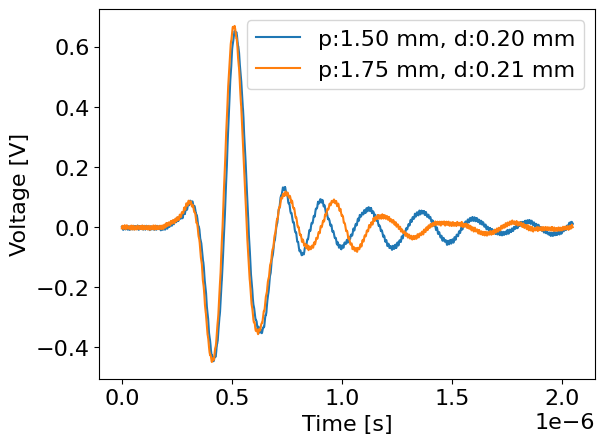

In [7]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt*len(sim_ref), sourse_new.exp_dt)
plt.plot(t, exp_rough, label='p:1.50 mm, d:0.20 mm')
plt.plot(t, exp_rough2, label='p:1.75 mm, d:0.21 mm')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.show()

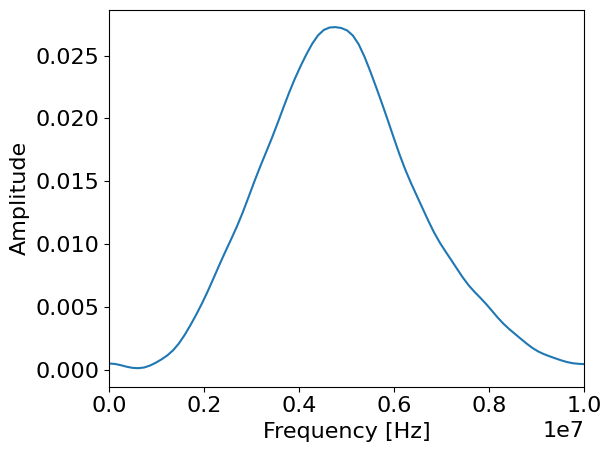

In [8]:
plt.figure()
plt.plot(freq, yf_exp_ref)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 10e6)
plt.tight_layout()
plt.show()

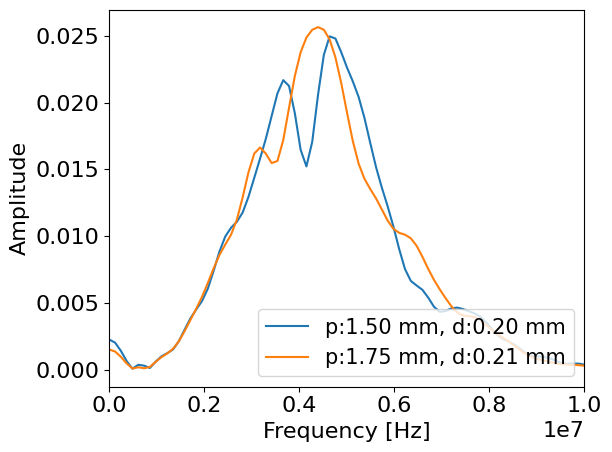

In [10]:
plt.figure()
plt.plot(freq, yf_exp_rough, label='p:1.50 mm, d:0.20 mm')
plt.plot(freq, yf_exp_rough2, label='p:1.75 mm, d:0.21 mm')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 10e6)
plt.tight_layout()
plt.legend(fontsize=15, loc='lower right')
plt.show()

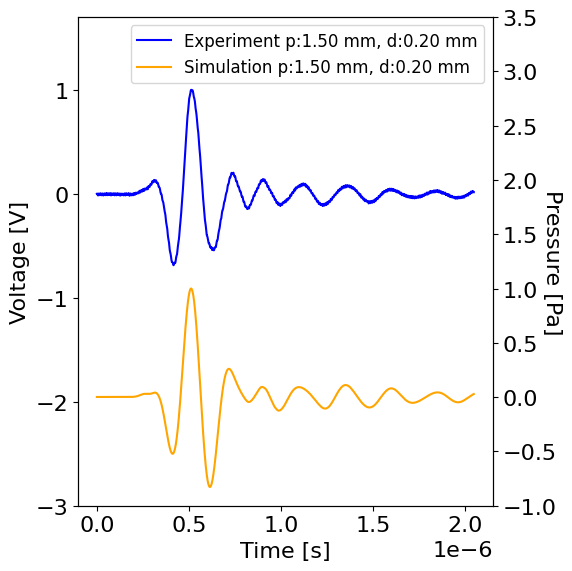

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt*len(sim_ref), sourse_new.exp_dt)

p1, = ax.plot(t, exp_rough/exp_rough.max(), label='Experiment p:1.50 mm, d:0.20 mm', color="blue")
p2, = twin1.plot(t, sim_rough/sim_rough.max(), label='Simulation p:1.50 mm, d:0.20 mm', color="orange")

text_y = twin1.get_ylim()[1] + 0.2  # 四角形の上端より少し上
fig.tight_layout()
ax.set_ylim(-3.0, 1.7)
twin1.set_ylim(-1.0, 3.5)
ax.set_xlabel('Time [s]',fontsize=16)
ax.set_ylabel('Voltage [V]',fontsize=16)
twin1.set_ylabel('Pressure [Pa]', rotation=270, fontsize=16)
# step4 凡例の追加
ax.legend(handles=[p1, p2],fontsize=12, loc='upper right')
plt.tight_layout()# 軸の目盛りラベルのフォントサイズを設定
ax.tick_params(axis='both', which='major', labelsize=16)  # 左のy軸と x軸
twin1.tick_params(axis='y', which='major', labelsize=16)  # 右のy軸
plt.show()


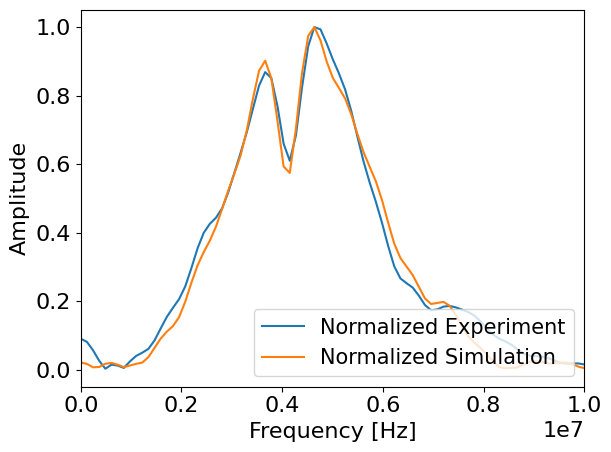

In [28]:
plt.figure()
plt.plot(freq, yf_exp_rough/yf_exp_rough.max(), label='Normalized Experiment')
plt.plot(freq, yf_sim_rough/yf_sim_rough.max(), label='Normalized Simulation')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 10e6)
plt.tight_layout()
plt.legend(fontsize=15, loc='lower right')
plt.show()